# Layer 3: training and evaluating the LSTM (StatsBomb 360)

This notebook trains the RQ3 LSTM on the track dataset built in `04_layer3_lstm_sequences.ipynb`. It evaluates the LSTM on the invisible teammates at passes in the 25 held-out test matches, measured as mean positional error in metres (the proposal's MAPE).

Before any training, section 2 scores two simple baselines on the same test examples:

- assuming the teammate is still exactly where they were last seen;
- the proposal's linear extrapolation from the last two points.

These are what the LSTM has to beat, and scoring them first also checks that the evaluation code produces sensible numbers. The PFF version of the LSTM is in `12_layer3_pff_rq3_lstm.ipynb`.

In [4]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATASET_DIR = Path('../data/lstm_dataset')
YARD_TO_M = 0.9144          # StatsBomb coordinates are in yards
MAX_SPEED = 10.0            # yards per second, same cap used in the linking

with open(DATASET_DIR / 'split.json') as fh:
    split = json.load(fh)
print({name: len(ids) for name, ids in split.items()})

try:
    import torch
    print(f"torch {torch.__version__}, GPU available: {torch.cuda.is_available()}")
except ImportError:
    print("torch is not installed yet, needed for the next section (pip install torch)")

{'test': 25, 'val': 25, 'train': 116}
torch 2.14.0+cpu, GPU available: False


## 1. The test examples

Each evaluation example is one invisible teammate at a qualifying pass in a test match. `hist` holds up to 15 earlier points of that teammate's track (x, y, time), right-aligned so the most recent point is always last, with unused slots empty. `target` is their true position and time at the pass. `n_hist` is how many earlier points exist.

In [5]:
def load_eval(match_ids):
    hist, target, meta = [], [], []
    for mid in match_ids:
        with open(DATASET_DIR / f'match_{mid}.pkl', 'rb') as fh:
            d = pickle.load(fh)
        hist.append(d['eval_hist'])
        target.append(d['eval_target'])
        meta.append(d['eval_meta'])
    return np.concatenate(hist), np.concatenate(target), pd.concat(meta, ignore_index=True)


test_hist, test_target, test_meta = load_eval(split['test'])

print(f"{len(test_meta)} evaluation examples in the {len(split['test'])} test matches")
for k in [1, 2, 5, 10]:
    print(f"  with at least {k:2d} earlier points: {(test_meta['n_hist'] >= k).mean():.1%}")

66569 evaluation examples in the 25 test matches
  with at least  1 earlier points: 63.3%
  with at least  2 earlier points: 47.5%
  with at least  5 earlier points: 16.4%
  with at least 10 earlier points: 3.1%


## 2. Two baselines

Last position assumes the teammate has not moved since they were last seen. It needs one earlier point.

Constant velocity is the proposal's linear extrapolation. It takes the velocity between the last two points and projects it forward to the moment of the pass. It needs two earlier points. The speed is capped at 10 yards per second, because two points recorded a fraction of a second apart, with a small amount of position noise, can otherwise imply a physically impossible speed.

The time between the last point and the pass (the horizon) is recorded too, since any method should get worse the longer a teammate has been out of sight.

In [6]:
def predict_last_position(hist):
    last = hist[:, -1]
    return last[:, 0], last[:, 1]


def predict_constant_velocity(hist, target, max_speed=MAX_SPEED):
    last, prev = hist[:, -1], hist[:, -2]
    dt = last[:, 2] - prev[:, 2]
    vx = (last[:, 0] - prev[:, 0]) / dt
    vy = (last[:, 1] - prev[:, 1]) / dt
    speed = np.hypot(vx, vy)
    scale = np.where(speed > max_speed, max_speed / speed, 1.0)
    horizon = target[:, 2] - last[:, 2]
    return last[:, 0] + vx * scale * horizon, last[:, 1] + vy * scale * horizon


def error_m(px, py, target):
    return np.hypot(px - target[:, 0], py - target[:, 1]) * YARD_TO_M


ev = test_meta.copy()
ev['horizon_s'] = test_target[:, 2] - test_hist[:, -1, 2]

with np.errstate(invalid='ignore', divide='ignore'):
    ev['err_last'] = error_m(*predict_last_position(test_hist), test_target)
    ev['err_cv'] = error_m(*predict_constant_velocity(test_hist, test_target), test_target)


def summarise(errors):
    e = errors.dropna()
    return pd.Series({
        'n': len(e),
        'mean_m': e.mean(),
        'median_m': e.median(),
        'within_3m': (e < 3).mean(),
        'within_4m': (e < 4).mean(),
        'within_5m': (e < 5).mean(),
    })


both = ev[ev['n_hist'] >= 2]   # the rows both baselines can score
print("Both baselines on the same teammates (at least 2 earlier points):")
print(pd.DataFrame({
    'last position': summarise(both['err_last']),
    'constant velocity': summarise(both['err_cv']),
}).round(3))
print()
print("Last position on everyone with at least 1 earlier point:")
print(summarise(ev.loc[ev['n_hist'] >= 1, 'err_last']).round(3))

Both baselines on the same teammates (at least 2 earlier points):
           last position  constant velocity
n              31634.000          31634.000
mean_m             3.073              4.517
median_m           2.545              3.616
within_3m          0.591              0.414
within_4m          0.740              0.550
within_5m          0.838              0.661

Last position on everyone with at least 1 earlier point:
n            42146.000
mean_m           3.176
median_m         2.644
within_3m        0.571
within_4m        0.723
within_5m        0.824
dtype: float64


In [7]:
both = both.copy()
both['history_bucket'] = pd.cut(both['n_hist'], [1, 2, 4, 9, 15],
                                 labels=['2', '3-4', '5-9', '10-15'], include_lowest=True)
both['horizon_bucket'] = pd.cut(both['horizon_s'], [0, 0.5, 1, 2, 5, 100],
                                labels=['0-0.5s', '0.5-1s', '1-2s', '2-5s', '5s+'], include_lowest=True)

print("Mean error (m) by number of earlier points:")
print(both.groupby('history_bucket')[['err_last', 'err_cv']].mean().round(2)
      .join(both.groupby('history_bucket').size().rename('n')))
print()
print("Mean error (m) by time since last seen:")
print(both.groupby('horizon_bucket')[['err_last', 'err_cv']].mean().round(2)
      .join(both.groupby('horizon_bucket').size().rename('n')))

Mean error (m) by number of earlier points:
                err_last  err_cv      n
history_bucket                         
2                   3.12    4.49  10201
3-4                 3.06    4.58  10537
5-9                 3.07    4.49   8825
10-15               2.96    4.39   2071

Mean error (m) by time since last seen:
                err_last  err_cv      n
horizon_bucket                         
0-0.5s              1.64    2.16   7392
0.5-1s              2.71    3.86   9539
1-2s                4.03    6.13  14703
2-5s                 NaN     NaN      0
5s+                  NaN     NaN      0


**What this shows**

On the 31634 test teammates with at least 2 earlier points, simply assuming the teammate has not moved is clearly better than the proposal's linear extrapolation: a mean error of 3.07 m against 4.52 m, a median of 2.55 m against 3.62 m, and 74.0 percent within 4 m against 55.0 percent. Across everyone with at least one earlier point, last position gives a mean error of 3.18 m.

The likely reason linear extrapolation does worse is noise. Freeze-frame positions are estimated from broadcast video and jitter by around a yard between frames. Dividing that jitter by a time gap of a fraction of a second produces a velocity that is mostly noise, and projecting it forward adds error rather than removing it, even with the speed cap.

The number of earlier points makes almost no difference to either baseline (3.12 m with 2 points against 2.96 m with 10 to 15), since both only use the last one or two points. The time since the teammate was last seen matters a great deal: last-position error grows from 1.64 m within half a second, to 2.71 m between half a second and 1 second, to 4.03 m between 1 and 2 seconds. No example is more than 2 seconds after its last point, because tracks end at gaps longer than that, so everything measured here is memory over the last two seconds at most.

This changes the bar the LSTM has to clear. The proposal compares the LSTM with linear extrapolation, but that is the weaker baseline here. The honest comparison is against last position, at 3.07 m on the shared rows. An LSTM that only beats linear extrapolation would not show anything useful. To be worth using, it has to beat simply assuming the teammate stood still, which it can do if it learns to use the whole history to separate real movement from position noise.

## 3. Training the LSTM

The model reads a teammate's history one point at a time and predicts how far they have moved from their last seen point by the moment of the target. For each earlier point it is given four things: where that point was relative to the last seen point, where it was on the pitch, and how long before the target it was recorded. Histories have different lengths, from 1 point up to the maximum allowed, and the LSTM reads each at its true length rather than padding them to a fixed size.

The loss is the straight-line distance between the predicted and true positions, which is exactly the error being reported, so the model is trained on the same thing it is judged on. It is a small network (two LSTM layers of 64 units), because the task is short-range.

Training uses a random 35 percent of the training examples, about a million, to keep memory use manageable. After each pass through the training data, the model is scored on the validation set: the invisible teammates at passes in the 25 validation matches. That is the same kind of example it will be tested on. Training stops when the validation error has not improved for three passes, and the best version is saved.

`K_MODEL` sets the maximum history length. It is 15 here, and the proposal's sensitivity check is to rerun this section with 5 and 10.

In [8]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

torch.manual_seed(0)
RESULTS_DIR = Path('../data/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

K_MODEL = 15          # longest history the model may use; rerun with 5 and 10 for the sensitivity check
SAMPLE_FRAC = 0.35    # share of training examples kept, to fit in memory
POS_SCALE = 10.0      # yards, divides positions and targets so the network sees values near 1
TIME_SCALE = 5.0      # seconds


def build_features(hist, target_t, k_max):
    """
    hist: (N, 15, 3) right-aligned history (x, y, time) with NaN padding.
    Returns features (N, k_max, 5) left-aligned for packing, the number of valid steps,
    and the last seen point. Per step: offset from the last seen point (dx, dy),
    position on the pitch (x, y scaled to 0-1), and time from that step to the target.
    """
    h = hist[:, -k_max:, :]
    n = (~np.isnan(h[:, :, 0])).sum(axis=1)
    last = h[:, -1, :]
    feats = np.zeros((len(h), k_max, 5), dtype=np.float32)
    feats[..., 0] = (h[..., 0] - last[:, None, 0]) / POS_SCALE
    feats[..., 1] = (h[..., 1] - last[:, None, 1]) / POS_SCALE
    feats[..., 2] = h[..., 0] / 120.0
    feats[..., 3] = h[..., 1] / 80.0
    feats[..., 4] = (target_t[:, None] - h[..., 2]) / TIME_SCALE
    feats = np.nan_to_num(feats, nan=0.0)
    # move padding to the end of each row, which is what pack_padded_sequence expects
    idx = (np.arange(k_max)[None, :] + (k_max - n)[:, None]) % k_max
    feats = np.take_along_axis(feats, idx[:, :, None], axis=1)
    return feats, n, last


def load_train(match_ids, k_max, frac, seed=0):
    rng = np.random.default_rng(seed)
    X, L, Y = [], [], []
    for mid in match_ids:
        with open(DATASET_DIR / f'match_{mid}.pkl', 'rb') as fh:
            d = pickle.load(fh)
        keep = rng.random(len(d['train_target'])) < frac
        hist, tgt = d['train_hist'][keep], d['train_target'][keep]
        feats, n, last = build_features(hist, tgt[:, 2], k_max)
        X.append(feats)
        L.append(n)
        Y.append(((tgt[:, :2] - last[:, :2]) / POS_SCALE).astype(np.float32))
    return np.concatenate(X), np.concatenate(L), np.concatenate(Y)


def eval_arrays(hist, target, meta, k_max):
    """Features for evaluation rows with at least one earlier point, plus their row positions."""
    rows = np.flatnonzero(meta['n_hist'].to_numpy() >= 1)
    feats, n, last = build_features(hist[rows], target[rows, 2], k_max)
    return feats, n, last, rows


t0 = time.time()
X_train, L_train, Y_train = load_train(split['train'], K_MODEL, SAMPLE_FRAC)
print(f"training examples: {len(X_train)} ({time.time() - t0:.0f}s to load)")

val_hist, val_target, val_meta = load_eval(split['val'])
X_val, L_val, last_val, rows_val = eval_arrays(val_hist, val_target, val_meta, K_MODEL)
print(f"validation examples (invisible teammates at passes, at least 1 earlier point): {len(X_val)}")

training examples: 962538 (2s to load)
validation examples (invisible teammates at passes, at least 1 earlier point): 42202


In [9]:
class TrajectoryLSTM(nn.Module):
    def __init__(self, n_features=5, hidden=64, layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        return self.head(h[-1])   # predicted movement from the last seen point, in units of POS_SCALE


def euclidean_loss(pred, target):
    return torch.linalg.norm(pred - target, dim=1).mean()


def predict(model, X, L, batch_size=8192):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[s:s + batch_size])
            lb = torch.from_numpy(L[s:s + batch_size].astype(np.int64))
            out.append(model(xb, lb).numpy())
    return np.concatenate(out) * POS_SCALE   # back to yards


def val_error_m(model):
    disp = predict(model, X_val, L_val)
    px, py = last_val[:, 0] + disp[:, 0], last_val[:, 1] + disp[:, 1]
    return error_m(px, py, val_target[rows_val]).mean()


model = TrajectoryLSTM()
print(model)
print(f"{sum(p.numel() for p in model.parameters())} trainable parameters")

TrajectoryLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)
55746 trainable parameters


In [10]:
EPOCHS = 12
BATCH_SIZE = 2048
PATIENCE = 3
MODEL_PATH = RESULTS_DIR / f'lstm_k{K_MODEL}.pt'

optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
X_t = torch.from_numpy(X_train)
L_t = torch.from_numpy(L_train.astype(np.int64))
Y_t = torch.from_numpy(Y_train)

history = []
best, bad_epochs = np.inf, 0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    order = torch.randperm(len(X_t))
    total, count = 0.0, 0
    for s in range(0, len(order), BATCH_SIZE):
        idx = order[s:s + BATCH_SIZE]
        optimiser.zero_grad()
        loss = euclidean_loss(model(X_t[idx], L_t[idx]), Y_t[idx])
        loss.backward()
        optimiser.step()
        total += loss.item() * len(idx)
        count += len(idx)

    train_m = total / count * POS_SCALE * YARD_TO_M
    val_m = val_error_m(model)
    history.append({'epoch': epoch, 'train_error_m': train_m, 'val_error_m': val_m})
    print(f"epoch {epoch:2d}: train {train_m:.3f} m, val {val_m:.3f} m ({time.time() - t0:.0f}s)")

    if val_m < best - 1e-4:
        best, bad_epochs = val_m, 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"no improvement for {PATIENCE} epochs, stopping")
            break

model.load_state_dict(torch.load(MODEL_PATH))
print(f"best validation error {best:.3f} m, model saved to {MODEL_PATH}")

epoch  1: train 3.426 m, val 3.089 m (49s)
epoch  2: train 3.390 m, val 3.069 m (47s)
epoch  3: train 3.380 m, val 3.067 m (47s)
epoch  4: train 3.376 m, val 3.065 m (47s)
epoch  5: train 3.374 m, val 3.063 m (47s)
epoch  6: train 3.372 m, val 3.062 m (47s)
epoch  7: train 3.370 m, val 3.058 m (47s)
epoch  8: train 3.367 m, val 3.057 m (46s)
epoch  9: train 3.365 m, val 3.058 m (46s)
epoch 10: train 3.363 m, val 3.055 m (46s)
epoch 11: train 3.361 m, val 3.057 m (46s)
epoch 12: train 3.359 m, val 3.054 m (46s)
best validation error 3.054 m, model saved to ..\data\results\lstm_k15.pt


## 4. Test results

The saved best model is scored on the invisible teammates at passes in the 25 test matches, which played no part in training or in choosing when to stop. It is compared with the two baselines on exactly the same teammates, first on everyone with at least one earlier point (last position and LSTM), then on everyone with at least two (all three methods), and broken down by time since last seen and by amount of history. Every test error is saved so it can be reused for the memory-feasibility threshold and the three-way RQ2 rerun.

In [11]:
X_test, L_test, last_test, rows_test = eval_arrays(test_hist, test_target, test_meta, K_MODEL)
disp = predict(model, X_test, L_test)
ev['err_lstm'] = np.nan
ev.loc[ev.index[rows_test], 'err_lstm'] = error_m(last_test[:, 0] + disp[:, 0],
                                                  last_test[:, 1] + disp[:, 1],
                                                  test_target[rows_test])

one = ev[ev['n_hist'] >= 1]
two = ev[ev['n_hist'] >= 2]
print("Everyone with at least 1 earlier point:")
print(pd.DataFrame({'last position': summarise(one['err_last']),
                    'LSTM': summarise(one['err_lstm'])}).round(3))
print()
print("At least 2 earlier points (all three methods on the same teammates):")
print(pd.DataFrame({'last position': summarise(two['err_last']),
                    'constant velocity': summarise(two['err_cv']),
                    'LSTM': summarise(two['err_lstm'])}).round(3))

one = one.copy()
one['horizon_bucket'] = pd.cut(one['horizon_s'], [0, 0.5, 1, 2],
                               labels=['0-0.5s', '0.5-1s', '1-2s'], include_lowest=True)
one['history_bucket'] = pd.cut(one['n_hist'], [0, 1, 2, 4, 9, 15],
                               labels=['1', '2', '3-4', '5-9', '10-15'])
print()
print("Mean error (m) by time since last seen:")
print(one.groupby('horizon_bucket')[['err_last', 'err_lstm']].mean().round(2)
      .join(one.groupby('horizon_bucket').size().rename('n')))
print()
print("Mean error (m) by number of earlier points:")
print(one.groupby('history_bucket')[['err_last', 'err_lstm']].mean().round(2)
      .join(one.groupby('history_bucket').size().rename('n')))

ev[['match_id', 'original_event_id', 'cand_x', 'cand_y', 'n_hist', 'horizon_s',
    'err_last', 'err_cv', 'err_lstm']].to_pickle(RESULTS_DIR / f'rq3_test_errors_k{K_MODEL}.pkl')

Everyone with at least 1 earlier point:
           last position       LSTM
n              42146.000  42146.000
mean_m             3.176      3.076
median_m           2.644      2.563
within_3m          0.571      0.588
within_4m          0.723      0.742
within_5m          0.824      0.838

At least 2 earlier points (all three methods on the same teammates):
           last position  constant velocity       LSTM
n              31634.000          31634.000  31634.000
mean_m             3.073              4.517      2.949
median_m           2.545              3.616      2.455
within_3m          0.591              0.414      0.612
within_4m          0.740              0.550      0.763
within_5m          0.838              0.661      0.855

Mean error (m) by time since last seen:
                err_last  err_lstm      n
horizon_bucket                           
0-0.5s              1.66      1.64   9461
0.5-1s              2.77      2.70  12726
1-2s                4.15      4.00  19959

M

**What this shows**

The LSTM beats both baselines on the test matches, but by a modest margin. On everyone with at least one earlier point (42146 teammates), its mean error is 3.08 m against 3.18 m for last position, its median 2.56 m against 2.64 m, and 74.2 percent are within 4 m against 72.3 percent. On teammates with at least two earlier points, where all three methods can be compared, it reaches 2.95 m against 3.07 m for last position and 4.52 m for linear extrapolation.

Where the gain comes from is informative. With only one earlier point there is no movement to learn from, and the LSTM is no better than last position (3.46 m against 3.48 m). The gain grows with the amount of history, to 0.16 m with 10 to 15 earlier points, and with the time since the teammate was last seen, from 0.02 m under half a second to 0.15 m between 1 and 2 seconds. That is the pattern expected if the model is genuinely learning movement from the history: it helps most where there is movement to learn and time for it to matter.

The ceiling is set by the data. Even within half a second of the last sighting, both methods are about 1.6 m out, which is mostly freeze-frame position noise and occasional tracking errors rather than anything a model could predict. Only part of the error comes from movement at all, and that is the only part the LSTM can reduce.

The validation error was still falling very slowly at the twelfth pass (3.058 to 3.054 m over the last four), so a longer run might gain a little more, but not enough to change these conclusions. The training error (3.36 m) is higher than the validation error because training uses every tracked point, including visible and fast-moving players, while validation only uses invisible teammates at passes.

For RQ3 so far: for the 63 percent of invisible teammates seen within the previous two seconds, an LSTM trained on their recent track places them with a mean error of about 3.1 m, and within 4 m about three times in four. That is better than both simple baselines, but only modestly better than assuming they have not moved.

### Is the LSTM's gain real?

A difference of 0.10 m on average could be chance. Examples from the same match are not independent, since they share players, tactics and camera conditions, so the uncertainty is estimated by resampling whole matches: the 25 test matches are drawn with replacement 5000 times and the average gain recomputed each time. If the resulting 95 percent interval stays above zero, the LSTM's advantage is not an accident of which matches ended up in the test set.

In [12]:
def match_bootstrap(df, worse, better, n_boot=5000, seed=0):
    """Average gain of `better` over `worse` (m, positive = better wins), with a 95% CI from resampling matches."""
    d = df[['match_id', worse, better]].dropna()
    d = d.assign(diff=d[worse] - d[better])
    per_match = d.groupby('match_id')['diff'].agg(['sum', 'count'])
    ids = per_match.index.to_numpy()
    rng_b = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        sub = per_match.loc[rng_b.choice(ids, size=len(ids), replace=True)]
        boot[b] = sub['sum'].sum() / sub['count'].sum()
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return pd.Series({
        'rows': len(d),
        'mean_gain_m': d['diff'].mean(),
        'ci_low_m': lo,
        'ci_high_m': hi,
        'share_rows_better': (d['diff'] > 0).mean(),
        'matches_better': f"{(per_match['sum'] > 0).sum()} of {len(per_match)}",
    })


print(pd.DataFrame({
    'LSTM vs last position (1+ points)': match_bootstrap(ev[ev['n_hist'] >= 1], 'err_last', 'err_lstm'),
    'LSTM vs constant velocity (2+ points)': match_bootstrap(ev[ev['n_hist'] >= 2], 'err_cv', 'err_lstm'),
}))

                  LSTM vs last position (1+ points)  \
rows                                          42146   
mean_gain_m                                0.099934   
ci_low_m                                   0.086042   
ci_high_m                                  0.113518   
share_rows_better                          0.563588   
matches_better                             25 of 25   

                  LSTM vs constant velocity (2+ points)  
rows                                              31634  
mean_gain_m                                    1.567631  
ci_low_m                                       1.490321  
ci_high_m                                      1.655293  
share_rows_better                              0.723051  
matches_better                                 25 of 25  


**What this shows**

The LSTM's advantage over last position is small but real. Its average gain is 0.10 m, with a 95 percent interval of 0.086 to 0.114 m when whole matches are resampled, so the interval stays well clear of zero. The LSTM also has the lower average error in all 25 test matches, not just on average across them, so the gain is not driven by a few unusual games.

The gain is consistent rather than large. It is about 3 percent of the 3.18 m error of last position, and for any single teammate the LSTM is closer only 56.4 percent of the time. In other words it wins slightly more often than it loses on individual teammates, and adds up to a reliable improvement across thousands of them.

Against the proposal's linear extrapolation the difference is much larger: an average gain of 1.57 m (95 percent interval 1.49 to 1.66 m), better for 72.3 percent of teammates and in all 25 matches. That confirms the earlier point that linear extrapolation is a weak baseline on this data, and that last position is the fair comparison.

So the honest statement for RQ3 is that the LSTM gives a statistically reliable but modest improvement over assuming a teammate has not moved, and a large improvement over the linear extrapolation the proposal named as its baseline.

## 5. Sensitivity to the maximum history length

The proposal specified history windows of 5, 10 and 15. Here these are the maximum number of earlier points the model may use. The same model is retrained from scratch with a maximum of 5 and of 10, using exactly the same training sample, settings and stopping rule as the main model with 15, and each version is scored on the same test teammates.

In [13]:
def train_and_test(k, epochs=12, batch_size=2048, patience=3, seed=0):
    """Retrain the LSTM with a maximum history of k points and score it on the test set.
    Uses its own local variables, so the main K = 15 model and `ev` are left untouched."""
    torch.manual_seed(seed)
    Xtr, Ltr, Ytr = load_train(split['train'], k, SAMPLE_FRAC)
    Xv, Lv, lastv, rowsv = eval_arrays(val_hist, val_target, val_meta, k)

    m = TrajectoryLSTM()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    Xt = torch.from_numpy(Xtr)
    Lt = torch.from_numpy(Ltr.astype(np.int64))
    Yt = torch.from_numpy(Ytr)
    path = RESULTS_DIR / f'lstm_k{k}.pt'

    best, bad = np.inf, 0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        m.train()
        order = torch.randperm(len(Xt))
        total, count = 0.0, 0
        for s in range(0, len(order), batch_size):
            idx = order[s:s + batch_size]
            opt.zero_grad()
            loss = euclidean_loss(m(Xt[idx], Lt[idx]), Yt[idx])
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
            count += len(idx)

        disp = predict(m, Xv, Lv)
        val_m = error_m(lastv[:, 0] + disp[:, 0], lastv[:, 1] + disp[:, 1], val_target[rowsv]).mean()
        train_m = total / count * POS_SCALE * YARD_TO_M
        print(f"K = {k}, epoch {epoch:2d}: train {train_m:.3f} m, val {val_m:.3f} m ({time.time() - t0:.0f}s)")

        if val_m < best - 1e-4:
            best, bad = val_m, 0
            torch.save(m.state_dict(), path)
        else:
            bad += 1
            if bad >= patience:
                print(f"K = {k}: no improvement for {patience} epochs, stopping")
                break

    m.load_state_dict(torch.load(path))
    Xte, Lte, lastte, rowste = eval_arrays(test_hist, test_target, test_meta, k)
    disp = predict(m, Xte, Lte)

    e = ev.drop(columns=['err_lstm']).copy()
    e['err_lstm'] = np.nan
    e.loc[e.index[rowste], 'err_lstm'] = error_m(lastte[:, 0] + disp[:, 0],
                                                 lastte[:, 1] + disp[:, 1],
                                                 test_target[rowste])
    e[['match_id', 'original_event_id', 'cand_x', 'cand_y', 'n_hist', 'horizon_s',
       'err_last', 'err_cv', 'err_lstm']].to_pickle(RESULTS_DIR / f'rq3_test_errors_k{k}.pkl')
    print(f"K = {k}: best validation error {best:.3f} m, saved model and test errors\n")
    return e


for k in [5, 10]:
    train_and_test(k)

K = 5, epoch  1: train 3.426 m, val 3.092 m (24s)
K = 5, epoch  2: train 3.395 m, val 3.070 m (23s)
K = 5, epoch  3: train 3.381 m, val 3.069 m (22s)
K = 5, epoch  4: train 3.378 m, val 3.066 m (23s)
K = 5, epoch  5: train 3.375 m, val 3.063 m (22s)
K = 5, epoch  6: train 3.373 m, val 3.060 m (22s)
K = 5, epoch  7: train 3.371 m, val 3.063 m (24s)
K = 5, epoch  8: train 3.368 m, val 3.062 m (24s)
K = 5, epoch  9: train 3.366 m, val 3.057 m (23s)
K = 5, epoch 10: train 3.364 m, val 3.059 m (23s)
K = 5, epoch 11: train 3.362 m, val 3.052 m (23s)
K = 5, epoch 12: train 3.361 m, val 3.054 m (23s)
K = 5: best validation error 3.052 m, saved model and test errors

K = 10, epoch  1: train 3.427 m, val 3.094 m (37s)
K = 10, epoch  2: train 3.394 m, val 3.072 m (38s)
K = 10, epoch  3: train 3.381 m, val 3.065 m (42s)
K = 10, epoch  4: train 3.377 m, val 3.063 m (34s)
K = 10, epoch  5: train 3.375 m, val 3.062 m (35s)
K = 10, epoch  6: train 3.372 m, val 3.059 m (37s)
K = 10, epoch  7: train 3.3

In [14]:
errors_by_k = {k: pd.read_pickle(RESULTS_DIR / f'rq3_test_errors_k{k}.pkl') for k in [5, 10, 15]}

comparison = {f'LSTM, K = {k}': summarise(e.loc[e['n_hist'] >= 1, 'err_lstm'])
              for k, e in errors_by_k.items()}
e15 = errors_by_k[15]
comparison['last position'] = summarise(e15.loc[e15['n_hist'] >= 1, 'err_last'])
print("Everyone with at least 1 earlier point:")
print(pd.DataFrame(comparison).round(3))
print()

# a longer maximum can only matter for teammates who actually have a long history,
# so compare the three models within each history bucket
by_history = pd.DataFrame({'n': e15.loc[e15['n_hist'] >= 1, 'n_hist']})
by_history['history_bucket'] = pd.cut(by_history['n'], [0, 1, 2, 4, 9, 15],
                                      labels=['1', '2', '3-4', '5-9', '10-15'])
for k, e in errors_by_k.items():
    by_history[f'K = {k}'] = e.loc[by_history.index, 'err_lstm']
by_history['last position'] = e15.loc[by_history.index, 'err_last']
print("Mean error (m) by number of earlier points:")
print(by_history.groupby('history_bucket')[[f'K = {k}' for k in [5, 10, 15]] + ['last position']]
      .mean().round(3)
      .join(by_history.groupby('history_bucket').size().rename('n')))

Everyone with at least 1 earlier point:
           LSTM, K = 5  LSTM, K = 10  LSTM, K = 15  last position
n            42146.000     42146.000     42146.000      42146.000
mean_m           3.071         3.070         3.076          3.176
median_m         2.558         2.551         2.563          2.644
within_3m        0.589         0.589         0.588          0.571
within_4m        0.743         0.743         0.742          0.723
within_5m        0.839         0.839         0.838          0.824

Mean error (m) by number of earlier points:
                K = 5  K = 10  K = 15  last position      n
history_bucket                                             
1               3.456   3.461   3.457          3.484  10512
2               3.003   3.011   3.010          3.117  10201
3-4             2.927   2.926   2.933          3.060  10537
5-9             2.931   2.915   2.932          3.066   8825
10-15           2.780   2.777   2.804          2.956   2071


**What this shows**

The maximum history length makes no practical difference. The three models have mean errors of 3.071 m (K = 5), 3.070 m (K = 10) and 3.076 m (K = 15) on the same test teammates, a spread of 0.006 m, far smaller than the 0.03 m width of the bootstrap interval for the main result. All three beat last position (3.176 m) by the same margin.

A longer maximum could only help teammates who actually have a long history, so the bucket breakdown is the real test. Even there it does not help: with 10 to 15 earlier points, K = 5 reaches 2.780 m and K = 15 reaches 2.804 m. The model draws what it needs from roughly the last five points, and older positions add nothing. This fits the rest of the RQ3 findings: what this data can support is short-term spatial memory over a second or two, not memory built up over longer stretches of play.

K = 10, the proposal's default window, is carried forward as the main model. It is tied for the lowest error, and the results for 5 and 15 show the conclusions do not depend on this choice.

In [15]:
e10 = errors_by_k[10]
print(pd.DataFrame({
    'LSTM K = 10 vs last position (1+ points)': match_bootstrap(e10[e10['n_hist'] >= 1], 'err_last', 'err_lstm'),
    'LSTM K = 10 vs constant velocity (2+ points)': match_bootstrap(e10[e10['n_hist'] >= 2], 'err_cv', 'err_lstm'),
}))

                  LSTM K = 10 vs last position (1+ points)  \
rows                                                 42146   
mean_gain_m                                       0.105528   
ci_low_m                                          0.091208   
ci_high_m                                         0.119748   
share_rows_better                                 0.566744   
matches_better                                    25 of 25   

                  LSTM K = 10 vs constant velocity (2+ points)  
rows                                                     31634  
mean_gain_m                                           1.576131  
ci_low_m                                              1.497827  
ci_high_m                                             1.663679  
share_rows_better                                     0.724758  
matches_better                                        25 of 25  


**What this shows**

The K = 10 model beats last position by an average of 0.106 m (95 percent interval 0.091 to 0.120 m, resampling whole matches), is closer for 56.7 percent of individual teammates, and has the lower average error in all 25 test matches. Against the proposal's linear extrapolation the gain is 1.576 m (95 percent interval 1.498 to 1.664 m), better for 72.5 percent of teammates and again in all 25 matches. These are essentially the same as for K = 15, as the sensitivity check predicted. This model is carried forward to define memory feasibility in the three-way RQ2 split.

## 6. Cross-fitting: out-of-sample predictions for all 166 matches

The three-way RQ2 split needs an LSTM error for every invisible teammate in all 166 matches, not only the 25 test matches. Using the main model's predictions on the matches it was trained on would make its errors look smaller than they really are, and would push too many teammates into the memory-feasible group.

Cross-fitting avoids this. The 166 matches are split at random into 5 groups of about 33. Five models are trained, each on four of the groups, and each one predicts only the group it never saw. Every match then gets predictions from a model that was never trained on it, the same honest standard as the test set.

Each model uses the main model's settings: a maximum history of 10 points, the same 35 percent training sample, and a fixed 12 passes. No validation set is needed, because early stopping never triggered in any earlier run, so every model simply trains for 12 passes as the main model did.

In [16]:
CF_K = 10          # main model's maximum history
CF_EPOCHS = 12     # same fixed number of passes as the main model (early stopping never triggered)
CF_FOLDS = 5
BATCH_SIZE = 2048
CF_DIR = RESULTS_DIR / 'crossfit'
CF_DIR.mkdir(parents=True, exist_ok=True)

# free the large training arrays from the main model section, if they are loaded
for name in ['X_train', 'L_train', 'Y_train', 'X_t', 'L_t', 'Y_t']:
    globals().pop(name, None)

all_ids = sorted(split['train'] + split['val'] + split['test'])
rng_cf = np.random.default_rng(42)
shuffled_ids = [str(m) for m in rng_cf.permutation(all_ids)]
folds = [shuffled_ids[i::CF_FOLDS] for i in range(CF_FOLDS)]
with open(CF_DIR / 'folds.json', 'w') as fh:
    json.dump(folds, fh, indent=1)
print("matches per fold:", [len(f) for f in folds])


def train_fixed(train_ids, k, epochs, seed):
    """Train a fresh LSTM for a fixed number of passes (no validation set needed)."""
    torch.manual_seed(seed)
    Xtr, Ltr, Ytr = load_train(train_ids, k, SAMPLE_FRAC, seed=seed)
    m = TrajectoryLSTM()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    Xt = torch.from_numpy(Xtr)
    Lt = torch.from_numpy(Ltr.astype(np.int64))
    Yt = torch.from_numpy(Ytr)
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        m.train()
        order = torch.randperm(len(Xt))
        total, count = 0.0, 0
        for s in range(0, len(order), BATCH_SIZE):
            idx = order[s:s + BATCH_SIZE]
            opt.zero_grad()
            loss = euclidean_loss(m(Xt[idx], Lt[idx]), Yt[idx])
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
            count += len(idx)
        print(f"    epoch {epoch:2d}: train {total / count * POS_SCALE * YARD_TO_M:.3f} m "
              f"({time.time() - t0:.0f}s)")
    return m


def predict_matches(m, match_ids, k):
    """Out-of-sample errors for every invisible teammate at a pass in these matches."""
    hist, target, meta = load_eval(match_ids)
    out = meta[['match_id', 'original_event_id', 'cand_x', 'cand_y', 'n_hist']].copy()
    out['horizon_s'] = target[:, 2] - hist[:, -1, 2]
    with np.errstate(invalid='ignore'):
        out['err_last_m'] = error_m(hist[:, -1, 0], hist[:, -1, 1], target)
    out['err_lstm_m'] = np.nan
    feats, n, last, rows = eval_arrays(hist, target, meta, k)
    disp = predict(m, feats, n)
    out.loc[out.index[rows], 'err_lstm_m'] = error_m(last[:, 0] + disp[:, 0],
                                                     last[:, 1] + disp[:, 1],
                                                     target[rows])
    return out

matches per fold: [34, 33, 33, 33, 33]


In [17]:
for f, held_out in enumerate(folds):
    out_path = CF_DIR / f'fold_{f}_predictions.pkl'
    if out_path.exists():
        print(f"fold {f}: already done, skipping")
        continue
    train_ids = [mid for i, fold in enumerate(folds) if i != f for mid in fold]
    print(f"fold {f}: training on {len(train_ids)} matches, predicting {len(held_out)}")
    t0 = time.time()
    m = train_fixed(train_ids, CF_K, CF_EPOCHS, seed=f)
    torch.save(m.state_dict(), CF_DIR / f'lstm_k{CF_K}_fold{f}.pt')
    preds = predict_matches(m, held_out, CF_K)
    preds['fold'] = f
    preds.to_pickle(out_path)
    print(f"fold {f}: done in {(time.time() - t0) / 60:.1f} min, {len(preds)} predictions saved\n")

fold 0: already done, skipping
fold 1: already done, skipping
fold 2: already done, skipping
fold 3: already done, skipping
fold 4: already done, skipping


In [18]:
cf = pd.concat([pd.read_pickle(CF_DIR / f'fold_{f}_predictions.pkl') for f in range(CF_FOLDS)],
               ignore_index=True)
cf.to_pickle(RESULTS_DIR / 'rq3_crossfit_predictions.pkl')
print(f"{len(cf)} invisible teammates across {cf['match_id'].nunique()} matches")
print(f"with at least 1 earlier point: {(cf['n_hist'] >= 1).mean():.1%}")
print()

cf1 = cf[cf['n_hist'] >= 1]
print("All 166 matches, everyone with at least 1 earlier point (every prediction out of sample):")
print(pd.DataFrame({'last position': summarise(cf1['err_last_m']),
                    'LSTM, cross-fitted': summarise(cf1['err_lstm_m'])}).round(3))
print()
print("Mean error (m) by fold:")
print(cf1.groupby('fold')[['err_last_m', 'err_lstm_m']].mean().round(3)
      .join(cf1.groupby('fold')['match_id'].nunique().rename('matches')))
print()
on_test = cf1[cf1['match_id'].isin(split['test'])]
print(f"On the 25 original test matches: cross-fitted LSTM {on_test['err_lstm_m'].mean():.3f} m, "
      f"main K = 10 model 3.070 m")

441065 invisible teammates across 166 matches
with at least 1 earlier point: 63.6%

All 166 matches, everyone with at least 1 earlier point (every prediction out of sample):
           last position  LSTM, cross-fitted
n             280469.000          280469.000
mean_m             3.161               3.053
median_m           2.610               2.525
within_3m          0.574               0.593
within_4m          0.725               0.743
within_5m          0.824               0.840

Mean error (m) by fold:
      err_last_m  err_lstm_m  matches
fold                                 
0          3.146       3.042       34
1          3.156       3.048       33
2          3.123       2.998       33
3          3.177       3.074       33
4          3.207       3.107       33

On the 25 original test matches: cross-fitted LSTM 3.073 m, main K = 10 model 3.070 m


**What this shows**

Every one of the 441065 invisible teammates in RQ2 now has a prediction from a model that never saw their match, and 63.6 percent have at least one earlier point, matching the dataset summary. Across all 166 matches, the cross-fitted LSTM has a mean error of 3.05 m against 3.16 m for last position, a median of 2.53 m against 2.61 m, and 74.3 percent within 4 m against 72.5 percent. That is the same gain of about 0.1 m found on the test set, now across the whole dataset.

The five models behave consistently. Each beats last position in its own group of matches by between 0.10 and 0.13 m, so no single group is carrying the result. On the 25 original test matches, the cross-fitted models reach 3.073 m against 3.070 m for the main K = 10 model, which confirms that training on different matches produces essentially the same model. These predictions are used to define memory feasibility in the three-way RQ2 split.

## 7. Figures

These cells make the summary chart in the shared colour scheme, from this notebook's own results, and save it to `../data/results/figures/`. They do not change any result.

The chart shows the mean error on the 25 test matches for teammates with at least 2 earlier points, where all three methods can be compared (K = 15 model, from the saved test errors). Only the first setup cell is needed.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# shared colours and style for the figures below
NAVY, GREEN, GREY, LIGHT, TXT = '#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0', '#1B1B1F'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#6B7280', 'axes.labelcolor': TXT,
                     'xtick.color': TXT, 'ytick.color': '#6B7280'})


def deck_bars(ax, labels, vals, colours, lo=None, hi=None, fmt='{:.1f}%', ymax=None, off=1.0):
    """Bar chart in the shared style, with optional confidence intervals and value labels."""
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colours, width=0.62)
    if lo is not None:
        ax.errorbar(x, vals, yerr=[np.subtract(vals, lo), np.subtract(hi, vals)],
                    fmt='none', ecolor=TXT, capsize=5, lw=1.2)
    for i, v in enumerate(vals):
        top = hi[i] if hi is not None else v
        ax.text(i, top + off, fmt.format(v), ha='center', va='bottom', fontsize=13, fontweight='bold', color=TXT)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    if ymax:
        ax.set_ylim(0, ymax)


saved ..\data\results\figures\rq3_lstm_summary.png


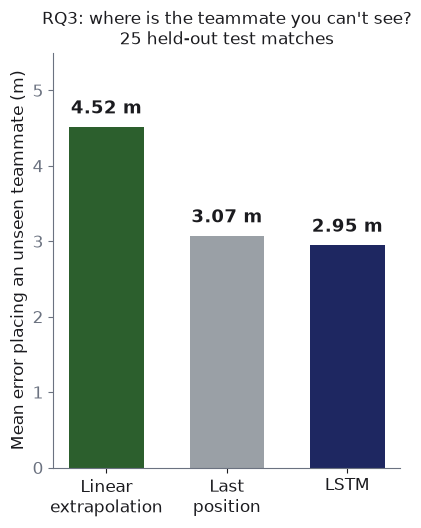

[4.52 3.07 2.95]


In [20]:
# LSTM chart: mean error on the 25 test matches, teammates with at least 2 earlier points
# (all three methods on the same teammates), K = 15 model, from the saved test errors.
e = pd.read_pickle(RESULTS_DIR / 'rq3_test_errors_k15.pkl')
e2 = e[e['n_hist'] >= 2]
vals = [e2['err_cv'].mean(), e2['err_last'].mean(), e2['err_lstm'].mean()]
fig, ax = plt.subplots(figsize=(4.48, 5.39))
deck_bars(ax, ['Linear\nextrapolation', 'Last\nposition', 'LSTM'], vals, [GREEN, GREY, NAVY],
          fmt='{:.2f} m', ymax=5.5, off=0.12)
ax.set_ylabel('Mean error placing an unseen teammate (m)')
ax.set_title("RQ3: where is the teammate you can't see?\n25 held-out test matches", fontsize=12, color=TXT)
save_fig(fig, 'rq3_lstm_summary.png')
plt.show()
print(np.round(vals, 2))

## Summary

**Last position is the baseline to beat, not linear extrapolation.** On test teammates with at least two earlier points, assuming the teammate has not moved gives 3.07 m against 4.52 m for the proposal's linear extrapolation. Freeze-frame jitter makes velocities unreliable.

**The LSTM beats both, modestly over last position.**

- It reaches 2.95 m on the same teammates, and 3.08 m against 3.18 m on everyone with at least one earlier point.
- The main K = 10 model gains 0.106 m over last position (95 percent CI 0.091 to 0.120, better in all 25 test matches) and 1.576 m over linear extrapolation.

**The history length does not matter.** K = 5, 10 and 15 give 3.071, 3.070 and 3.076 m.

**Cross-fitted predictions for all 166 matches** give 3.05 m against 3.16 m for last position, with 74.3 percent of invisible teammates within 4 m. They define memory feasibility in `07_layer3_memory_feasibility.ipynb` and `06_layer3_blind_passes.ipynb`.

With continuous PFF tracking and memory defined from the passer's own cone, the LSTM's advantage is much larger (3.03 m against 4.06 m for last seen; `12_layer3_pff_rq3_lstm.ipynb`).